In [1]:
import pandas as pd
df = pd.read_csv("../data/processed/merged_interactions.csv")

In [2]:
df.head()

,UserID,MovieID,Rating,Timestamp,Title,Genres,Gender,Age,Occupation,Zip,Datetime
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067,2000-12-31 22:12:40
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067,2000-12-31 22:35:09
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067,2000-12-31 22:32:48
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067,2000-12-31 22:04:35
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067,2001-01-06 23:38:11


In [3]:
df.shape

(1000209, 11)

In [4]:
df.dtypes

UserID         int64
MovieID        int64
Rating         int64
Timestamp      int64
Title         object
Genres        object
Gender        object
Age            int64
Occupation     int64
Zip           object
Datetime      object
dtype: object

In [5]:
df.isnull().sum()

UserID        0
MovieID       0
Rating        0
Timestamp     0
Title         0
Genres        0
Gender        0
Age           0
Occupation    0
Zip           0
Datetime      0
dtype: int64

In [6]:
df['UserID'].nunique(), df['MovieID'].nunique()

(6040, 3706)

In [7]:
df['Zip'].value_counts()

Zip
94110         3802
60640         3430
98103         3204
95616         3079
02138         3019
              ... 
90732           20
954025          20
77565-2332      20
97838           20
14706           20
Name: count, Length: 3439, dtype: int64

In [8]:
int_col,obj_col = df.select_dtypes(include='int64').columns.tolist(),df.select_dtypes(include="object").columns.tolist()

In [9]:
int_col

['UserID', 'MovieID', 'Rating', 'Timestamp', 'Age', 'Occupation']

<Axes: xlabel='Rating', ylabel='Count'>

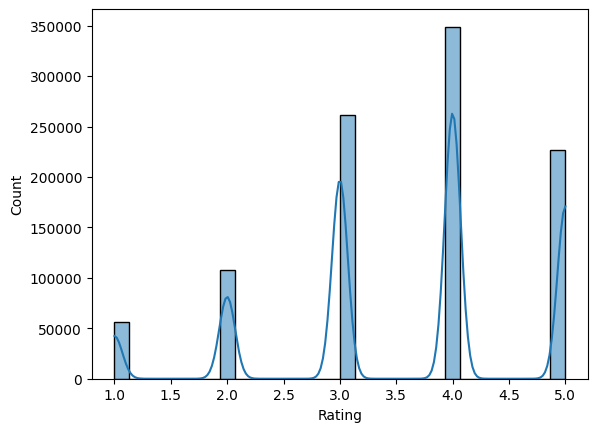

In [10]:
import seaborn as sns
sns.histplot(df[int_col[2]], kde=True, bins=30)

20 2314 count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64


<Axes: >

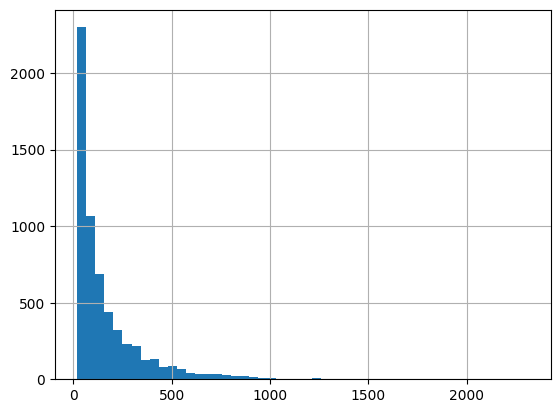

In [11]:
user_counts = df.groupby('UserID').size()
print(user_counts.min(), user_counts.max(), user_counts.describe())
user_counts.hist(bins=50)

<Axes: >

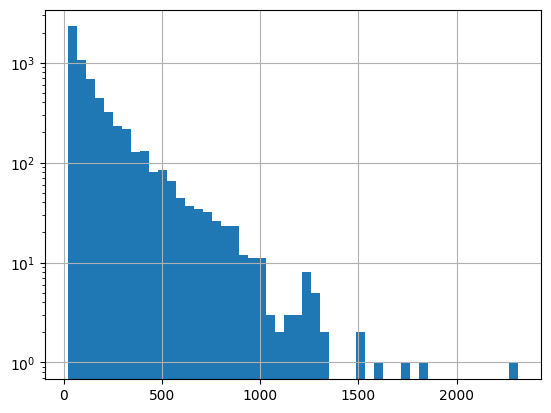

In [12]:
user_counts.hist(bins=50, log=True)

2000-04-25 23:05:32 2003-02-28 17:49:50


<Axes: xlabel='Datetime'>

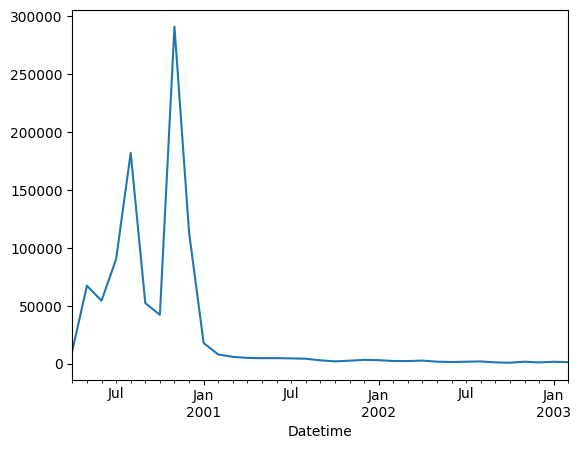

In [15]:
df["Datetime"] = df["Datetime"].astype("datetime64[ns]") 
print(df['Datetime'].min(), df['Datetime'].max())
df.set_index('Datetime').resample('ME').size().plot()

Genres
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
Name: count, dtype: int64


<Axes: xlabel='Genres'>

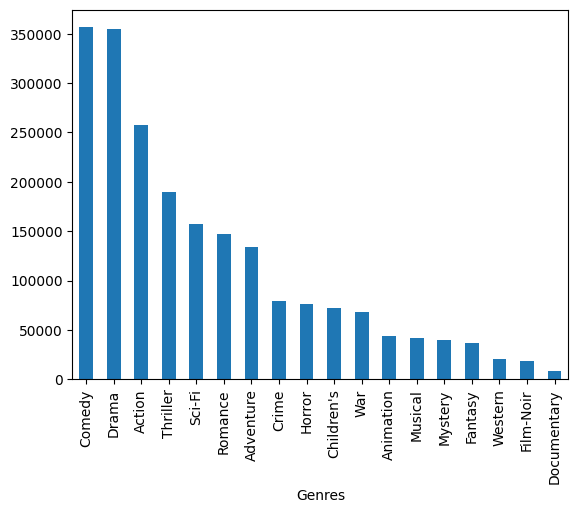

In [16]:
genre_counts = df['Genres'].str.split('|').explode().value_counts()
print(genre_counts)
genre_counts.plot(kind='bar')